In [33]:
# ================================================
# 1. 라이브러리 import
# ================================================

# [시스템 및 파일 경로 제어]
import os       # 파일 경로 생성, 디렉토리(폴더) 존재 여부 확인 등 OS 기능 사용
import glob     # 특정 확장자(예: *.wav, *.png)를 가진 파일들의 경로를 패턴으로 한 번에 긁어올 때 사용
import random   # 무작위 추출이나 데이터 셔플(섞기)을 위한 라이브러리
import shutil   # 파일 복사, 이동, 삭제 등 파일 시스템 조작을 쉽게 해주는 라이브러리 (데이터셋 분할 시 유용)

# [데이터 분석 및 수치 연산]
import numpy as np      # 다차원 배열(Array) 연산, 수학 연산 및 데이터 처리를 위한 필수 라이브러리
import pandas as pd     # 표(DataFrame) 형태의 데이터(예: 학습 로그, 메타데이터 CSV 파일)를 다루기 위한 라이브러리
import matplotlib.pyplot as plt  # 데이터나 오디오 파형, 학습 곡선(Loss, Accuracy) 등을 시각화(그래프 그리기)하는 도구
import seaborn as sns            # matplotlib을 기반으로 더 예쁘고 통계적인 그래프(예: 혼동 행렬 시각화)를 그려주는 도구

# [오디오 데이터 처리]
import librosa          # 음성/오디오 신호 처리(로드, 변환, 특징 추출 등)를 위한 파이썬 표준 라이브러리
import librosa.display  # librosa로 추출한 오디오 특징(예: 스펙트로그램, 파형)을 시각적으로 보여주는 도구

# [이미지 처리]
from PIL import Image   # 파이썬에서 이미지를 열고, 수정하고, 저장하는 기본 이미지 처리 라이브러리 (Pillow)

# [머신러닝 평가 및 딥러닝(TensorFlow/Keras)]
from sklearn.metrics import classification_report, confusion_matrix  # 모델의 분류 성능(정밀도, 재현율, 혼동 행렬 등)을 분석하는 평가지표
import tensorflow as tf             # 구글에서 개발한 오픈소스 딥러닝 프레임워크 핵심 라이브러리
from tensorflow.keras import layers, models  # 딥러닝 모델의 뼈대(models)와 신경망 층(layers: CNN, Dense 등)을 쌓기 위한 모듈
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # 이미지를 자동으로 불러오고 증강(Augmentation)해주는 데이터 파이프라인 도구
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # 학습 자동 중단(EarlyStopping) 및 최적의 모델 가중치 저장(ModelCheckpoint) 콜백 함수

# [기타 설정]
import warnings
warnings.filterwarnings('ignore')  # 코드가 실행될 때 뜨는 불필요하거나 번잡한 경고(Warning) 메시지를 화면에 출력하지 않도록 숨김

# Jupyter Notebook 환경에서 plt.show()를 매번 호출하지 않아도 그래프가 셀 바로 아래에 즉시 출력되도록 설정하는 매직 명령어
%matplotlib inline

# [랜덤 시드 고정]
# 코드 실행 시마다 결과가 달라지지 않고, 언제나 동일한 실험 결과를 얻을 수 있도록(재현성 보장) 난수 생성 기준점을 42로 통일
SEED = 42
random.seed(SEED)          # 기본 random 라이브러리 시드 고정
np.random.seed(SEED)       # 넘파이(numpy) 연산 시드 고정
tf.random.set_seed(SEED)   # 텐서플로우(TensorFlow) 딥러닝 가중치 초기화 시드 고정





In [34]:
# ================================================
# 2. 기본 경로 및 전역 하이퍼파라미터 설정
# ================================================

BASE_DIR = os.getcwd()                                                 # root dir 설정
AUDIO_DIR = os.path.join(BASE_DIR, "audio")                            # 오디오 파일이 저장된 루트 폴더

SPEC_DIR = os.path.join(BASE_DIR, "spectrogram_data")                  # 오디오를 이미지로 변환하여 저장할 루드 디렉토리
SPLIT_DIR = os.path.join(BASE_DIR, "spectrogram_split")                # ai 학습용으로 train/test/val 구조로 저장할 폴더

BEST_MODEL_PATH = os.path.join(BASE_DIR, "best_instrument_cnn_model.keras")   # 최종 학습 모델 결과 저장 파일
TEMP_PREDICT_IMAGE_PATH = os.path.join(BASE_DIR, "temp_predict_spectrogram.png")  # 신규 예측시 임시로 스펙트로그램 이미지를 저장할 경로

CLASSES = ['cello', 'flute', 'oboe', 'sax', 'trumpet', 'viola']    # 분류 대상 클래스  <-- 폴더명과 일치하도록 정의

# CNN 입력 이미지 높이
IMG_HEIGHT = 224

# CNN 입력 이미지 너비
IMG_WIDTH = 224

# 최적화된 Signal Processing 파라미터 설정
SR = 44100                 # 샘플링 주파수 (고음질 유지)
DURATION = 0.8             # 변경: 1.5 -> 0.8 (불필요한 뒷부분 공백을 잘라내어 소리만 꽉 차게 만듦)
SAMPLES_PER_TRACK = int(SR * DURATION)

N_FFT = 2048               # FFT 윈도우 길이 (세로축/주파수 해상도 유지)
HOP_LENGTH = 256           # 변경: 1024 -> 256 (간격을 4배 좁혀서 가로축/시간 해상도를 엄청나게 선명하게 만듦)
N_MELS = 128               # 변경: 126 -> 128 (CNN 모델이 처리하기 가장 좋은 2의 거듭제곱 표준 크기)

BATCH_SIZE = 16            
EPOCHS = 20






In [35]:
# ================================================
# 3. 유효성 검사 및 공통 유틸리티 함수
# ================================================

def ensure_directory_exists(dir_path):
    '''
    지정한 디렉토리가 존재하지 않으면 생성
    '''
    os.makedirs(dir_path, exist_ok=True)

def validate_audio_directory_structure(audio_dir, classes):
    '''
    audio 폴더와 클래스별 하위 폴더가 존재하는지 확인
    '''
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[오류] audio 루트 폴더를 찾을 수 없습니다 : {audio_dir}")

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 클래스 폴더가 없습니다 : {class_dir}")


def count_audio_files(audio_dir, classes, extension="*.mp3"):
    '''
    클래스 별 오디오 파일 개수를 집계하여 dict 형태로 변환
    '''
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extension)
        counts[cls] = len(glob.glob(pattern))
    return counts

def validate_minimum_files_per_class(file_counts, minimum_count=3):
    '''
    각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
    '''
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(
                f"[오류] 클래스 '{cls}'의 파일 수가 너무 적습니다."
                f"최소 {minimum_count}개 이상 필요하지만 현재 {count}개입니다."
            )

def safe_remove_path(path):
    '''
    파일 또는 디렉토리가 존재할 때만 삭제
    '''
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)

def print_section_title(title):
    '''
    노트북에서 색션 구분이 명확하게 보이도록 제목 출력
    '''
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)




데이터 폴더 및 파일 개수 확인
원본 오디오 루트 경로: C:\Users\human3_03\Desktop\workspace\DeepLearning\audio
스펙트로그램 저장 경로: C:\Users\human3_03\Desktop\workspace\DeepLearning\spectrogram_data
분할 데이터 저장 경로: C:\Users\human3_03\Desktop\workspace\DeepLearning\spectrogram_split
     Class  Count
0    cello    100
1    flute    100
2     oboe    100
3      sax    100
4  trumpet    100
5    viola    100


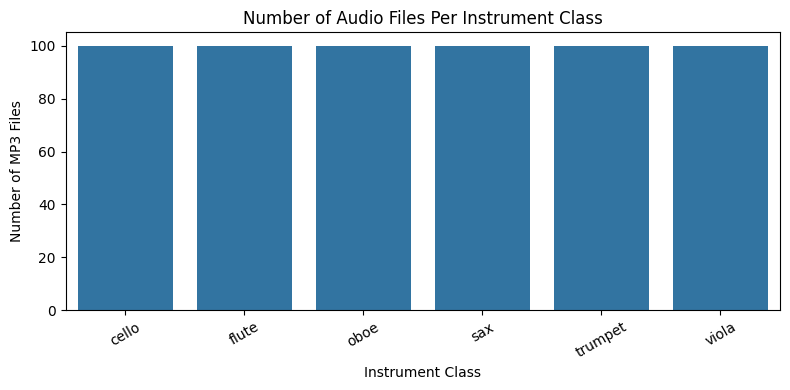

In [36]:
# ================================================
# 4. 데이터 폴더 구조 및 파일 개수 확인
# ================================================
# audio 폴더와 클래스별 하위 폴더가 실제로 존재하는지 검증
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

# 클래스 별 MP3 개수 집계
file_counts = count_audio_files(AUDIO_DIR, CLASSES, extension='*.mp3')

# 각 클래스가 최소한의 샘플 수를 갖는지 확인
validate_minimum_files_per_class(file_counts, minimum_count=3)

# 집계 결과를 데이터프레임으로 변환
file_count_df = pd.DataFrame(list(file_counts.items()), columns=["Class", "Count"])

# 현재 데이터 구성 상황을 출력
print_section_title("데이터 폴더 및 파일 개수 확인")
print("원본 오디오 루트 경로:", AUDIO_DIR)
print("스펙트로그램 저장 경로:", SPEC_DIR)
print("분할 데이터 저장 경로:", SPLIT_DIR)
print(file_count_df)

#클래스별 데이터 불균형 여부를 시각화하여 확인
plt.figure(figsize=(8,4))
sns.barplot(data=file_count_df, x= "Class", y= "Count")
plt.title("Number of Audio Files Per Instrument Class")
plt.xlabel("Instrument Class")
plt.ylabel("Number of MP3 Files")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [37]:
# ================================================
# 5. 오디오 로드 함수 정의
# ================================================

def load_audio_file(file_path, sr=SR, duration=DURATION):
    '''
    오디오 파일을 모노 신호로 읽고, 지정 길이로 고정
     - 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다
     - 너무 짧은 파일은 zero-padding 한다
     - 너무 긴 파일은 앞부분을 사용한다
    '''
    # 입력 경로가 문자열인지 확인
    if not isinstance(file_path, str):
        raise TypeError(f"[오류] file_path는 문자열이어야 합니다. 현재 타입 : {type(file_path)}")

    # 실제 파일 존재 여부 확인
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[오류] 오디오 파일이 존재하지 않습니다 : {file_path}")

    # 파일 확장자 확인
    valid_exts = [".mp3", ".wav", ".flac", ".ogg", ".m4a"]
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_exts:
        raise ValueError(f"[오류] 지원하지 않는 오디오 확장자입니다 : {ext}")

    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"[오류] 오디오 로드 실패 : {file_path}\n원인 : {e}")

    # 비어 있는 배열이 들어오면 이후 FFT/STFT에서 실패하므로 사전 차단
    if y is None or len(y) == 0:
        raise ValueError(f"[오류] 오디어 데이터가 비어있습니다 : {file_path}")

    # 목표 샘플 길이 계산
    target_length = int(sr * duration)

    # 길이가 짧으면 뒤를 0으로 패딩하여 고정 길이를 맞춘다
    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')

    # 길이가 길면 앞부분만 사용
    else:
        y = y[:target_length]

    return y, sr





In [38]:
# ================================================
# 6. 샘플 오디오 파일 1개 선택 및 기본 분석
# ================================================

# 데이터 시각화 예제로 사용할 첫 번째 샘플 분석
sample_file = None
sample_class = None

for cls in CLASSES:
    pattern = os.path.join(AUDIO_DIR, cls, "*.mp3")
    files = glob.glob(pattern)
    if len(files) > 0:
        sample_file = files[0]
        sample_class = cls
        break

# 샘플 파일을 하나도 찾지 못한 경우 즉시 에러 발생
if sample_file is None:
    raise FileNotFoundError("[오류] 샘플로 사용할 mp3 파일을 찾지 못했습니다.")

# 샘플 파일 로드
y_sample, sr_sample = load_audio_file(sample_file)

# 샘플 파일 정보 출력
print("샘플 클래스 : ", sample_class)
print("샘플 파일 : ", sample_file)
print("샘플링 주파수 : ", sr_sample)
print("총 샘플 수 : ", len(y_sample))
print("총 길이(초) : ", len(y_sample) / sr_sample)



    

샘플 클래스 :  cello
샘플 파일 :  C:\Users\human3_03\Desktop\workspace\DeepLearning\audio\cello\cello_A2_025_forte_arco-normal.mp3
샘플링 주파수 :  44100
총 샘플 수 :  35280
총 길이(초) :  0.8


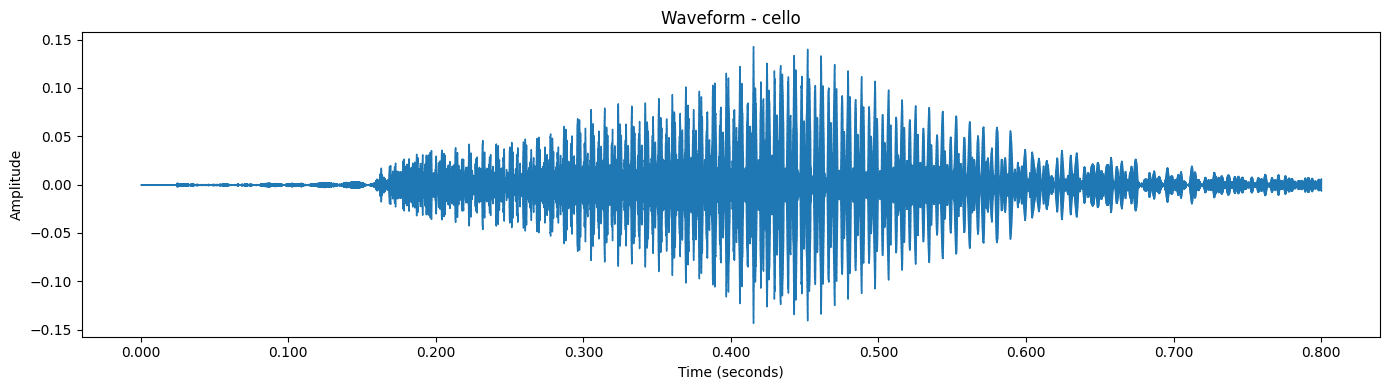

In [39]:
# ================================================
# 7. 샘플 오디오 waveplot 시각화
# ================================================

# wave 파형은 시간축에서 신호 진폭이 어떻게 변하는지 보여줌 (dB)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y_sample, sr=sr_sample)
plt.title(f"Waveform - {sample_class}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

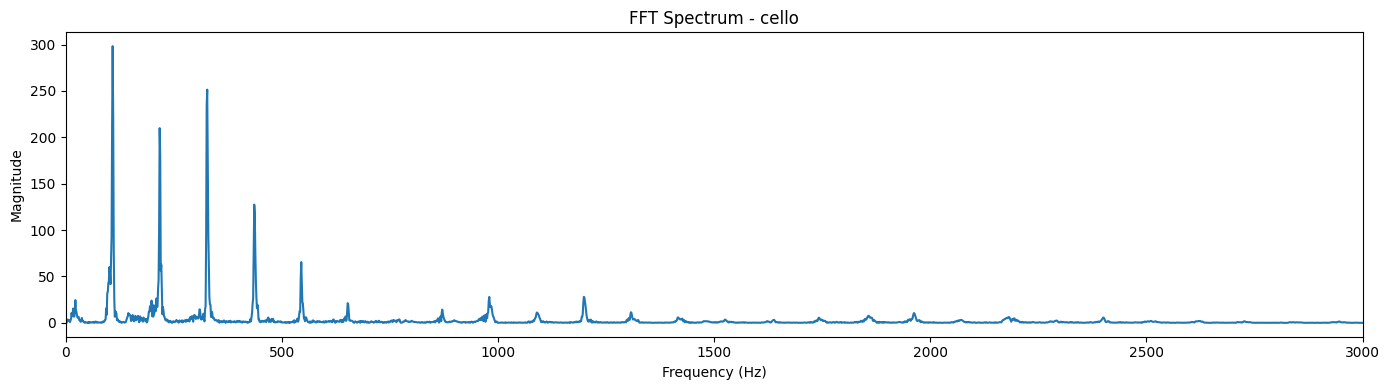

In [40]:
# ================================================
# 8. 샘플 오디오 FFT 시각화 (주파수 데이터로 변환)
# ================================================

# FFT : 시간영역 신호를 주파수영역으로 변환하여 어떤 주파수 성분이 강한지 확인
fft_sample = np.fft.fft(y_sample)

# 복소수 푸리에 계수의 절대값을 취해서 magnitude spectrum을 계산
magnitude_sample = np.abs(fft_sample)

# 각 인덱스가 실제 어떤 주파수에 대응하는지 계산
freqs_sample = np.fft.fftfreq(len(magnitude_sample), d=1 / sr_sample)

# 실수 신호 fft가 음수 주파수 구간이 대칭이므로 양수 영역만 사용
positive_freqs_sample = freqs_sample[:len(freqs_sample) // 2]
positive_magnitude_sample = magnitude_sample[:len(magnitude_sample) // 2]

# fft 시각화
plt.figure(figsize=(14,4))
plt.plot(positive_freqs_sample, positive_magnitude_sample)
plt.title(f"FFT Spectrum - {sample_class}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 3000)
plt.tight_layout()
plt.show()




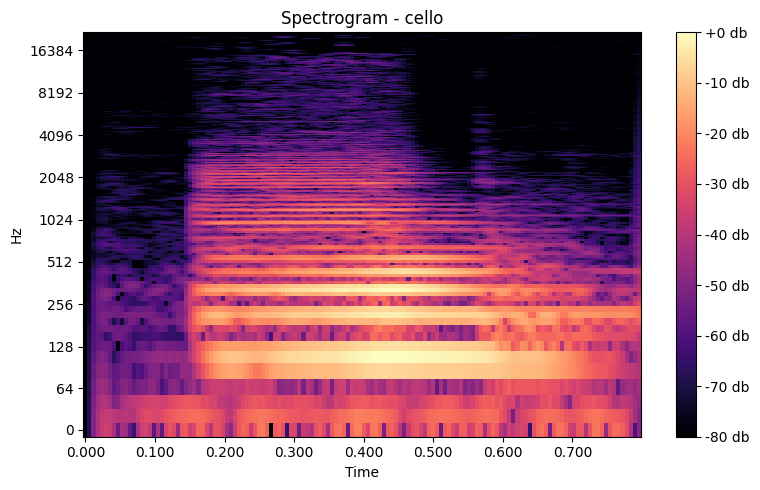

In [41]:
# ================================================
# 9. 샘플 오디오 STFT Spectrogram 시각화
# ================================================
# STFT : 짧은 시간 구간별로 FFT를 수행하여 시간-주파수 2차원으로 시그널 표현
stft_sample = librosa.stft(y_sample, n_fft=N_FFT, hop_length=HOP_LENGTH)

# 복소수 stft 결과의 절대값을 취하여 magnitude spectrogram 생성
spectrogram_sample = np.abs(stft_sample)

# 사람의 청각 및 신호 에너지 해석에 유리하도록 dB 스케일로 변환
spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref=np.max)

# 로그 주파수축 Spectrogram 그리기
plt.figure(figsize=(8,5))
librosa.display.specshow(
    spectrogram_db_sample,
    sr=sr_sample,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='log',
    cmap='magma'
)
plt.colorbar(format='%+2.0f db')
plt.title(f"Spectrogram - {sample_class}")
plt.tight_layout()
plt.show()





In [46]:
# ================================================
# 10. 오디오 파일에 대해 Spectrogram 이미지 저장하는 함수
# ================================================
def save_spectrogram_image(audio_path, save_path, sr=SR, duration=DURATION):
    # 저장 경로의 상위 폴더가 존재하도록 보장
    save_dir = os.path.dirname(save_path)

    # save_path가 현재 작업 디렉토리 바로 아래 파일일 경우 dirname이 빈 문자열일 수 있음
    if save_dir != "":
        ensure_directory_exists(save_dir)

    # 오디오 로드
    y, sr = load_audio_file(audio_path, sr=sr, duration=duration)

    # melspectrogram 계산
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    # power spectrogram을 dB로 변환
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    fig = plt.figure(figsize=(4,4))

    # 축/눈금 없이 스펙트럼 패턴만 저장되도록 그리기
    librosa.display.specshow(
        mel_spec_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis=None,
        y_axis=None,
        cmap='magma'
    )

    # cnn이 의미 없는 축 텍스트를 학습하지 않도록 축 제거
    plt.axis('off')

    # 저장 시 여백 최소화
    plt.tight_layout(pad=0)

    # png로 저장
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)

    # 메모리 정리를 위해 figure를 닫는다
    plt.close(fig)

    # 저장된 이미지를 열어 rgb로 변환 후 입력 크기로 통일
    img = Image.open(save_path).convert("RGB")
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    img.save(save_path)

    

In [47]:
# ================================================
# 11. 전체 오디오 파일 --> Spectrogram 이미지 생성
# ================================================

# 이전 실행 결과가 남아 있으면 삭제
safe_remove_path(SPEC_DIR)

# Spectrogram 루트폴더 생성
ensure_directory_exists(SPEC_DIR)   # spectrogram_data 폴더
print_section_title("스펙트로그램 이미지 생성 시작")

# 클래스별로 모든 mp3 파일을 순회하면서 spectrogram 이미지를 생성
for cls in CLASSES:
    class_audio_dir = os.path.join(AUDIO_DIR, cls)
    class_spec_dir = os.path.join(SPEC_DIR, cls)

    #클래스 별 spectrogram 저장 폴더 생성
    ensure_directory_exists(class_spec_dir)

    # 해당 클래스의 mp3 목록 가져오기
    audio_files = glob.glob(os.path.join(class_audio_dir, "*.mp3"))

    # 처리 현황 출력
    print(f"{cls}: {len(audio_files)}개 파일 처리 중....")

    # 각 파일을 spectrogram으로 변환
    for audio_file in audio_files:
        base_name = os.path.splitext(os.path.basename(audio_file))[0]
        save_path = os.path.join(class_spec_dir, f"{base_name}.png")
        save_spectrogram_image(audio_file, save_path)

print("스펙트로그램 이미지 생성 완료")


스펙트로그램 이미지 생성 시작
cello: 100개 파일 처리 중....
flute: 100개 파일 처리 중....
oboe: 100개 파일 처리 중....
sax: 100개 파일 처리 중....
trumpet: 100개 파일 처리 중....
viola: 100개 파일 처리 중....
스펙트로그램 이미지 생성 완료


In [49]:
# ================================================
# 12. train/test/val 분할 함수
# ================================================

def split_dataset_to_folders(source_dir, target_dir, classes, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    '''
    스펙트로그램 이미지를 클래스 별로 train/test 폴더 구조로 분할
    '''

    # 기존 split 폴더 삭제
    safe_remove_path(target_dir)

    # 비율의 합이 1인지 검증
    if abs(train_ratio + val_ratio + test_ratio - 1.0) >= 1e-6:
        raise ValueError("[오류] train_ratio + val_ratio + test_ratio의 합은 반드시 1이어야 함")

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        # 원본 클래스 이미지가 존재하는지 확인
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 스펙트로그램 클래스 폴더가 없습니다 : {class_dir}")

        image_files = glob.glob(os.path.join(class_dir, "*.png"))

        # 클래스별 이미지가 없으면 학습 불가이므로 중단
        if len(image_files) == 0:
            raise ValueError(f"[오류] 클래스 '{cls}'의 스펙트로그램 이미지가 없습니다.")

        # 무작위 셔플 후 분할
        random.shuffle(image_files)

        n_total = len(image_files)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_files = image_files[:n_train]
        val_files = image_files[n_train:n_train + n_val]
        test_files = image_files[n_train + n_val:]

        # split 별 폴더를 생성
        for split_name in ["train", "val", "test"]:
            ensure_directory_exists(os.path.join(target_dir, split_name, cls))

        # 복사 보조 함수
        def copy_files(files, split_name):
            for f in files:
                dst = os.path.join(target_dir, split_name, cls, os.path.basename(f))
                shutil.copy2(f, dst)

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

        print(f"{cls} -> tratin : {len(train_files)}, val : {len(val_files)}, test : {len(test_files)}")

# split 이후 각 폴더에 최소 1개 이상의 이미지가 있는지 검증
def validate_split_dataset(target_dir, classes):
    print_section_title("분할 데이터셋 검증")
    for split_name in ["train", "val", "test"]:
        print(f"[{split_name}]")
        for cls in classes:
            class_dir = os.path.join(target_dir, split_name, cls)
            count = len(glob.glob(os.path.join(class_dir, "*.png")))
            print(f"{cls} : {count}개")
            if count == 0:
                raise ValueError(
                    f"[오류] {split_name} / {cls} 폴더에 이미지가 없습니다."
                    f"클래스별 샘플수가 너무 적거나 분할 비율 조정이 필요합니다."
                )




    

In [50]:
# ================================================
# 13. 데이터셋 분할 수행
# ================================================

print_section_title("train/val/test 분할 시작")
split_dataset_to_folders(SPEC_DIR, SPLIT_DIR, CLASSES, train_ratio=0.7,
                        val_ratio=0.15, test_ratio=0.15)
validate_split_dataset(SPLIT_DIR, CLASSES)
print("데이터 분할 완료")


train/val/test 분할 시작
cello -> tratin : 70, val : 15, test : 15
flute -> tratin : 70, val : 15, test : 15
oboe -> tratin : 70, val : 15, test : 15
sax -> tratin : 70, val : 15, test : 15
trumpet -> tratin : 70, val : 15, test : 15
viola -> tratin : 70, val : 15, test : 15

분할 데이터셋 검증
[train]
cello : 70개
flute : 70개
oboe : 70개
sax : 70개
trumpet : 70개
viola : 70개
[val]
cello : 15개
flute : 15개
oboe : 15개
sax : 15개
trumpet : 15개
viola : 15개
[test]
cello : 15개
flute : 15개
oboe : 15개
sax : 15개
trumpet : 15개
viola : 15개
데이터 분할 완료


In [51]:
# ================================================
# 14. ImageDataGenerator 설정
# ================================================


train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

# 검증/테스트 데이터는 모델 평가의 일관성을 위해 정규화 수행
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# train generator 생성
train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# val generator 생성
val_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# test generator 생성
test_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 클래스 인덱스 매핑을 출력
print_section_title("클래스 인덱스 매핑")
print(train_generator.class_indices)

# index -> class 이름 역매핑을 미리 만들어둔다.
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
print("역매핑:", idx_to_class)

Found 420 images belonging to 6 classes.
Found 90 images belonging to 6 classes.
Found 90 images belonging to 6 classes.

클래스 인덱스 매핑
{'cello': 0, 'flute': 1, 'oboe': 2, 'sax': 3, 'trumpet': 4, 'viola': 5}
역매핑: {0: 'cello', 1: 'flute', 2: 'oboe', 3: 'sax', 4: 'trumpet', 5: 'viola'}


In [52]:
# ================================================
# 15. CNN 모델 정의
# ================================================

# 입력 SHAPE은 고정된 스팩트로그램 RGB 이미지 크기
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# Sequential 모델 생성
model = models.Sequential()

# 1 convolution layer : 저수준 edge/texture 패턴을 추출
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
model.add(layers.MaxPool2D((2,2)))

# 2 convolution layer : 중간 수준의 패턴 조합을 추출
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPool2D((2,2)))

# 3 convolution layer : 더 복잡한 주파수 특징, 하모닉 구조, 시간-주파수 패턴을 학습
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPool2D((2,2)))

# 4 convolution layer : 클래스 구분력이 높은 상위 수준의 특성 추출
model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPool2D((2,2)))

# feature map을 1차원 벡터로 변환
model.add(layers.Flatten())

model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))     # 학습의 과적합 방지를 위해 드롭아웃 적용

# 최종 출력층 (6개 클래스 확률 분포를 생성)
model.add(layers.Dense(len(CLASSES), activation='softmax'))

model.summary()















Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      12,845,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,235,270 (50.49 MB)

 Trainable params: 13,235,270 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# 모델 컴파일 설정
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)









In [54]:
# ================================================
# 16. 학습 콜백 설정
# ================================================

# validation loss가 일정 epoch 동안 개선되지 않으면 학습을 종료
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# validation accuracy가 최고일 때 모델을 자동으로 저장
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)




In [56]:
# ================================================
# 17. 모델 학습
# ================================================

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint]
)









Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.2307 - loss: 1.8631
Epoch 1: val_accuracy improved from None to 0.54444, saving model to C:\Users\human3_03\Desktop\workspace\DeepLearning\best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3238 - loss: 1.6520 - val_accuracy: 0.5444 - val_loss: 1.1083
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5417 - loss: 1.1337
Epoch 2: val_accuracy improved from 0.54444 to 0.58889, saving model to C:\Users\human3_03\Desktop\workspace\DeepLearning\best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.5524 - loss: 1.1302 - val_accuracy: 0.5889 - val_loss: 0.8470
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6341 - loss: 0.8873
Epoch 3: val_accuracy improved from 0.58889 to 0.70000, saving model to C:\Users\human3_03\Desktop\workspace\DeepLearning\best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6762 -

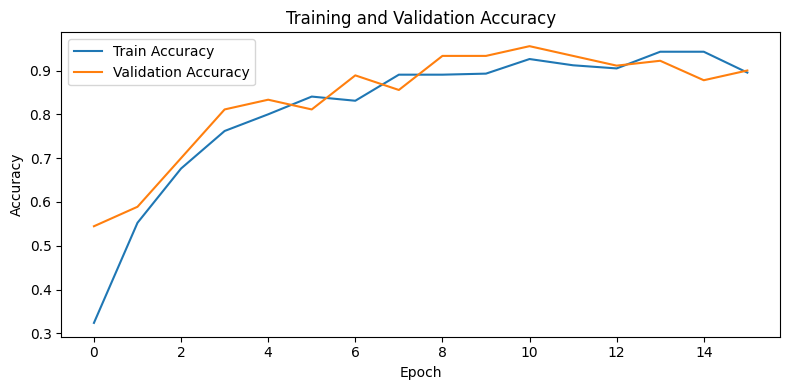

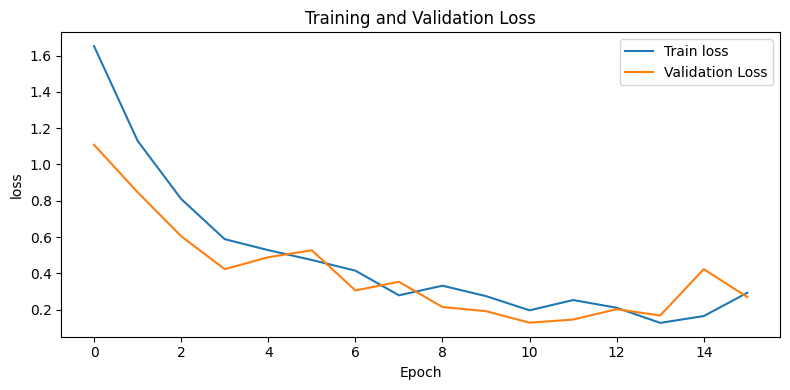

In [57]:
# ================================================
# 18. 학습 과정 시각화
# ================================================

# 결과 시각화
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step

분류 리포트
              precision    recall  f1-score   support

       cello       0.75      1.00      0.86        15
       flute       1.00      1.00      1.00        15
        oboe       1.00      1.00      1.00        15
         sax       1.00      0.93      0.97        15
     trumpet       1.00      1.00      1.00        15
       viola       0.91      0.67      0.77        15

    accuracy                           0.93        90
   macro avg       0.94      0.93      0.93        90
weighted avg       0.94      0.93      0.93        90



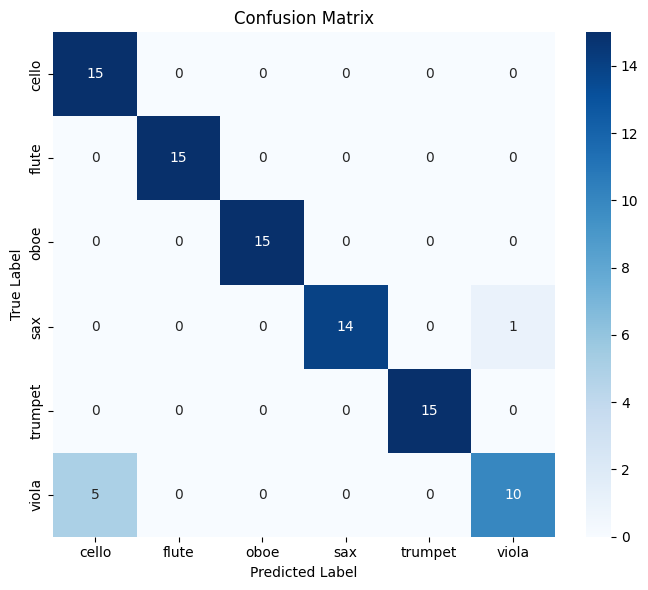

In [59]:
# ================================================
# 19. 테스트셋 분류 리포트 및 confusion matrix 확인
# ================================================

# 테스트셋 전체에 대해 클래스별 확률을 예측
pred_probs = model.predict(test_generator)

# 가장 큰 확률을 갖는 인덱스를 최종 예측 클래스로 사용
pred_classes = np.argmax(pred_probs, axis=1)

# 실제 정답 라벨
true_classes = test_generator.classes

# 클래스 이름 목록
class_labels = list(test_generator.class_indices.keys())

print_section_title("분류 리포트")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    zero_division=0
))

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [69]:
# ================================================
# 20. 예측용 오디오 분석/시각화 함수
# ================================================

def visualize_audio_analysis(audio_path, predicted_class=None, probs_dict=None):
    '''
    신규 입력 오디오에 대해 waveplot, fft, spectrogram을 순차적으로 시각화
    '''
    # 오디오 로드
    y, sr = load_audio_file(audio_path)

    # 파일명만 표시용으로 추출
    file_name = os.path.basename(audio_path)

    # 1) waveplot 시각화
    plt.figure(figsize=(14,4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Input Audio Waveform - {file_name}")
    plt.xlabel("Time (Second)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # 2) FFT 시각화
    fft_vals = np.fft.fft(y)
    magnitude = np.abs(fft_vals)
    freqs = np.fft.fftfreq(len(magnitude), d=1 / sr)
    positive_freqs = freqs[:len(freqs) // 2]
    positive_magnitude = magnitude[:len(magnitude) // 2]

    plt.figure(figsize=(14,4))
    plt.plot(positive_freqs, positive_magnitude)
    plt.title(f"Input Audio FFT Spectrum - {file_name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.tight_layout()
    plt.show()

    # 3) 스펙트로그램 시각화
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(14,4))
    librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='log'
    )
    plt.colorbar(format='%+2.0f db')
    if predicted_class is None:
        plt.title(f"Input Audio Spectrogram - {file_name}")
    else:
        plt.title(f"Input Audio Spectrogram - {file_name}\nPredicted : {predicted_class}")

    plt.tight_layout()
    plt.show()

    # 4) 예측 확률 막대 그래프
    if probs_dict is not None:
        probs_df = pd.DataFrame({
            "Class" : list(probs_dict.keys()),
            "Probability" : list(probs_dict.values())
        }).sort_values("Probability", ascending=False)
    
        plt.figure(figsize=(8,4))
        sns.barplot(data=probs_df, x="Class", y="Probability")
        plt.title(f"Predicted Probability - {file_name}")
        plt.xlabel("Instrument Class")
        plt.ylabel("Probability")
        plt.xticks(rotation=30)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()








    

In [74]:
# ================================================
# 21. 신규 오디오 예측 함수
# ================================================

def predict_instrument_from_audio_absolute_path(audio_path, model, class_indices, save_temp_image=False):
    """
    절대경로로 지정한 신규 오디오 파일을 읽어와 CNN으로 예측한다.

    기능:
    - 입력 파일 유효성 검사
    - spectrogram 임시 이미지 생성
    - 모델 추론
    - 예측 클래스 및 확률 반환
    - 입력 오디오 waveplot / FFT / spectrogram / 확률 시각화 수행
    """

    # 입력값 타입 검증
    if not isinstance(audio_path, str):
        raise TypeError("[오류] audio_path는 문자열이어야 합니다.")

    # 절대경로인지 확인한다. 사용자 요청 조건을 강제하기 위한 검증.
    if not os.path.isabs(audio_path):
        raise ValueError(f"[오류] 신규 오디오 예측 경로는 절대경로여야 합니다: {audio_path}")

    # 실제 파일 존재 여부 확인
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"[오류] 신규 예측용 오디오 파일이 존재하지 않습니다: {audio_path}")

    # 모델 유효성 확인
    if model is None:
        raise ValueError("[오류] 학습된 모델이 없습니다.")

    # 클래스 인덱스 매핑 확인
    if not isinstance(class_indices, dict) or len(class_indices) == 0:
        raise ValueError("[오류] class_indices가 비어 있거나 유효하지 않습니다.")

    # 임시 spectrogram 이미지가 남아 있으면 삭제
    if os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    # 신규 오디오를 spectrogram 이미지로 변환
    save_spectrogram_image(audio_path, TEMP_PREDICT_IMAGE_PATH)

    # 임시 이미지가 실제 생성되었는지 확인
    if not os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        raise FileNotFoundError("[오류] 예측용 임시 spectrogram 이미지 생성에 실패했습니다.")

    # 저장된 이미지를 열어 RGB 변환
    img = Image.open(TEMP_PREDICT_IMAGE_PATH).convert("RGB")

    # 모델 입력 크기로 리사이즈
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    # numpy 배열로 변환 후 0~1 범위로 정규화
    img_array = np.array(img).astype("float32") / 255.0

    # (H, W, C) -> (1, H, W, C)로 배치 축을 추가
    img_array = np.expand_dims(img_array, axis=0)

    # 모델 추론을 수행한다.
    probs = model.predict(img_array, verbose=0)[0]

    # 최대 확률 클래스 인덱스를 찾는다.
    pred_idx = int(np.argmax(probs))

    # index -> class 역매핑 생성
    idx_to_class_local = {v: k for k, v in class_indices.items()}

    # 예측 클래스 이름
    predicted_class = idx_to_class_local[pred_idx]

    # 클래스별 확률 dict 생성
    probs_dict = {idx_to_class_local[i]: float(probs[i]) for i in range(len(probs))}

    # 예측용 spectrogram 이미지 자체를 보여준다.
    plt.figure(figsize=(5, 5))
    plt.imshow(Image.open(TEMP_PREDICT_IMAGE_PATH))
    plt.title(f"Prediction Spectrogram\nPredicted: {predicted_class}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 입력 오디오의 wave/FFT/spectrogram/확률을 함께 시각화
    visualize_audio_analysis(
        audio_path=audio_path,
        predicted_class=predicted_class,
        probs_dict=probs_dict
    )

    # 임시 저장을 원하지 않으면 삭제
    if not save_temp_image and os.path.exists(TEMP_PREDICT_IMAGE_PATH):
        os.remove(TEMP_PREDICT_IMAGE_PATH)

    return predicted_class, probs_dict


신규 오디오 예측 준비
절대경로 :  C:\Users\human3_03\Desktop\workspace\DeepLearning\new_audio\flute_A5_1_forte_normal.mp3


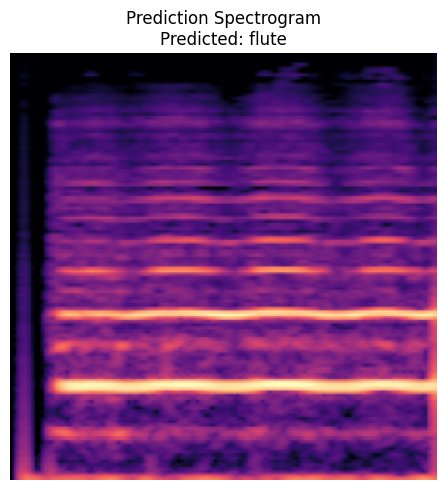

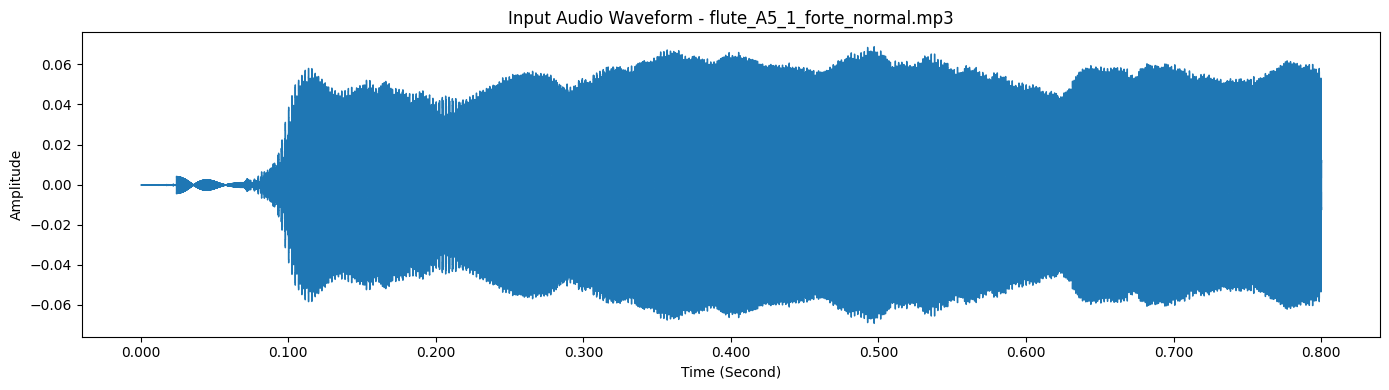

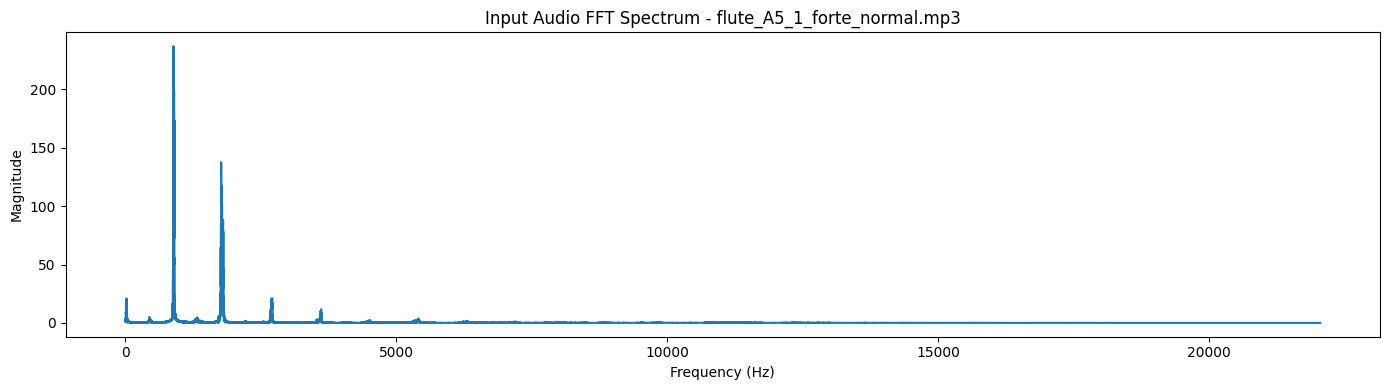

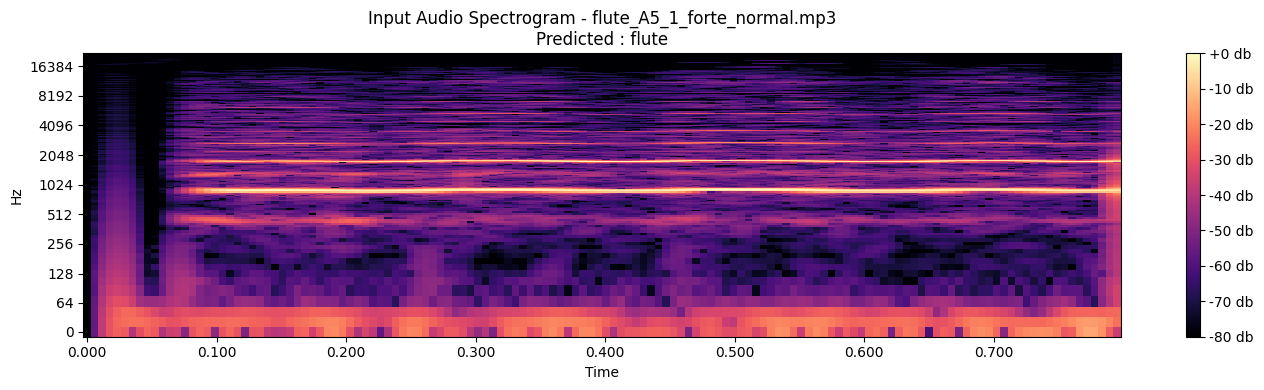

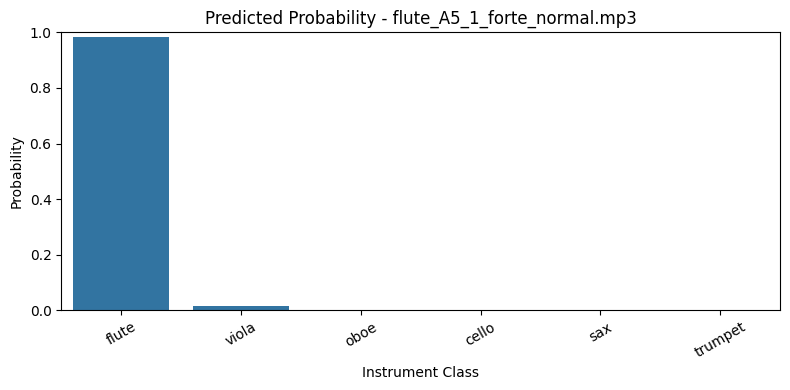


 예측 클래스 :  flute

 클래스 별 예측 확률 : 
flute : 0.9825
viola : 0.0155
oboe : 0.0011
cello : 0.0008
sax : 0.0000
trumpet : 0.0000


In [75]:
# ================================================
# 22. 신규 오디오 예측 결과 수행
# ================================================

NEW_AUDIO_ABSOLUTE_PATH = r"C:\Users\human3_03\Desktop\workspace\DeepLearning\new_audio\flute_A5_1_forte_normal.mp3"

print_section_title("신규 오디오 예측 준비")
print("절대경로 : ", NEW_AUDIO_ABSOLUTE_PATH)

if os.path.exists(NEW_AUDIO_ABSOLUTE_PATH):
    predicted_class, probs_dict = predict_instrument_from_audio_absolute_path(
    audio_path=NEW_AUDIO_ABSOLUTE_PATH,
    model=model,
    class_indices=train_generator.class_indices,
    save_temp_image=False
    )

    print("\n 예측 클래스 : ", predicted_class)
    print("\n 클래스 별 예측 확률 : ")
    for cls, prob in sorted(probs_dict.items(), key=lambda x: x[1], reverse=True):
        print(f"{cls} : {prob:.4f}")
else:
    print("NEW_AUDIO_ABSOLUTE_PATH를 실제 존재하는 절대경로로 수정한 뒤 예측을 실행하세요.")


